In [31]:
import os
import warnings

import umap
import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import cdist


warnings.filterwarnings("ignore")


In [14]:
def find_path(file_name):
    return os.path.join(os.getcwd(), file_name)

def run_kmeans(X, k):
    
    model = KMeans(n_clusters=k, n_init="auto")
    labels = model.fit_predict(X)
    return model, labels
    
def opt_kmeans(X):

    silhouette_scores = []
    inertia_scores = []
    k_range = range(2, 11)
    for k in k_range:
        model, labels = run_kmeans(X, k)
        inertia_scores.append(model.inertia_)
        sil_score = silhouette_score(X, labels)
        silhouette_scores.append(sil_score)


    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(k_range, inertia_scores, marker='o')
    ax[0].set_title("Elbow Method (Inertia)")
    ax[0].set_xlabel("Number of clusters (k)")
    ax[0].set_ylabel("Inertia")

    ax[1].plot(k_range, silhouette_scores, marker='o', color='green')
    ax[1].set_title("Silhouette Score")
    ax[1].set_xlabel("Number of clusters (k)")
    ax[1].set_ylabel("Silhouette Score")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
    best_k = k_range[np.argmax(silhouette_scores)]
    print(f" Best k by silhouette: {best_k} )")

    return best_k, inertia_scores, silhouette_scores




df_raw = pd.read_csv(find_path("train.csv"))
desc_cols = [col for col in df_raw.columns if col.startswith("job_desc_")]

In [15]:
X_scaled = StandardScaler().fit_transform(df_raw[desc_cols])
X_pca = PCA(n_components=90).fit_transform(X_scaled)
X_pca

In [18]:
X_pca.shape

(1280, 300)

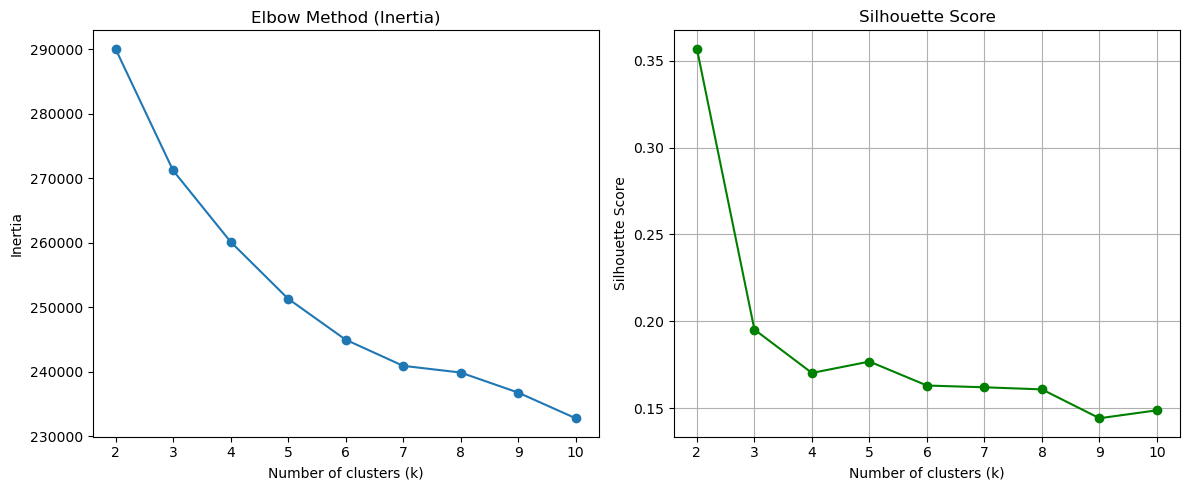

✅ Best k by silhouette: 2 )


In [19]:
best_k, inertia_vals, sil_scores = opt_kmeans(X_pca)
kmeans_model, kmeans_labels = run_kmeans(X_pca, best_k)


In [12]:
features = pd.DataFrame(index=np.arange(X_pca.shape[0]))

# KMeans cluster label feature
features['kmeans_cluster_label'] = kmeans_labels

In [13]:
distances_km = cdist(X_pca, kmeans_model.cluster_centers_, metric='euclidean')
dist_to_centroid = distances_km[np.arange(X_pca.shape[0]), kmeans_labels]
features['kmeans_dist_to_centroid'] = dist_to_centroid

In [14]:
features.to_csv(find_path("features_kmeans.csv"), index=False)

In [49]:




def get_reducer(method, n_components, random_state):
    if method == "umap":
        return umap.UMAP(n_components=n_components, random_state=random_state)
    elif method == "tsne":
        return TSNE(n_components=n_components, random_state=random_state, perplexity=30, n_iter=1000)
    else:
        raise ValueError(f"Unsupported reduction method: {method}")

def get_cluster_labels(method, X, n_clusters=None, random_state=42):
    if method == "kmeans":
        return KMeans(n_clusters=n_clusters, n_init="auto", random_state=random_state).fit_predict(X)
    elif method == "dbscan":
        return DBSCAN(eps=0.5, min_samples=5).fit_predict(X)
    else:
        raise ValueError(f"Unsupported clustering method: {method}")


In [66]:
def visualize_jobdesc_clusters(
    df, desc_cols, clustering_method="kmeans", n_clusters=3,
    pca_components=60, methods=["umap_2d", "tsne_3d"], random_state=42, file_name2save_plot =None
):

    # clustering_method = kmean, dbscan
    
    # 1. Scale
    X = df[desc_cols].values
    X_scaled = StandardScaler().fit_transform(X)

    # 2. PCA
    X_pca = PCA(n_components=pca_components, random_state=random_state).fit_transform(X_scaled)

    # 3. Clustering
    cluster_labels = get_cluster_labels(clustering_method, X_pca, n_clusters=n_clusters, random_state=random_state)

    # 4. Vis
    for method in methods:
        base_method, dim_str = method.split("_")
        n_components = 3 if dim_str == "3d" else 2
        reducer = get_reducer(base_method, n_components=n_components, random_state=random_state)
        X_embedded = reducer.fit_transform(X_pca)

        # Prepare 2 vis
        columns = ['x', 'y'] if n_components == 2 else ['x', 'y', 'z']
        df_vis = pd.DataFrame(X_embedded, columns=columns)
        df_vis['cluster'] = cluster_labels.astype(str)

        # Plot
        title = f"{method.upper()} projection with {clustering_method.upper()} clustering"
        fig = px.scatter(df_vis, x='x', y='y', color='cluster', title=title) if n_components == 2 \
              else px.scatter_3d(df_vis, x='x', y='y', z='z', color='cluster', title=title)
        file_name2save_plot = f"{method}_{clustering_method}.html"
        fig.write_html(os.path.join(os.getcwd(), file_name2save_plot))



In [67]:
visualize_jobdesc_clusters(df_raw, desc_cols, clustering_method="kmeans", n_clusters=5, methods=["umap_2d", "umap_3d", "tsne_2d", "tsne_3d"])

